In [1]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import spearmanr, pearsonr


In [2]:
df = pd.read_excel("../data/tested_variants/2023-04-07 Sequence Activity Dataset.xlsx", sheet_name=0)
df_pure = df.iloc[1:].copy()

df_pure.columns = ["entry", "name", "parent", "parent_mutations", "aa_sequence", 
              "1_mol_hydroxylation1", "1_mol_hydroxylation2", "1_mol_azidation", 
              "10_mol_hydroxylation1", "10_mol_hydroxylation2", "10_mol_azidation"]
df_pure.drop(columns="entry", inplace=True)
#df_pure            

## Lysate vs Purified protein

In [3]:
df = pd.read_excel("../data/tested_variants/2023-04-07 Sequence Activity Dataset.xlsx", sheet_name=1)
df_lysate = df.copy()
df_lysate.columns = ["entry", "name", "parent", "parent_mutations", "aa_sequence",
                    "10_mol_hydroxylation1", "10_mol_hydroxylation2", "10_mol_azidation"]
df_lysate.drop(columns="entry", inplace=True)

df_lysate

,name,parent,parent_mutations,aa_sequence,10_mol_hydroxylation1,10_mol_hydroxylation2,10_mol_azidation
0,4-IC H172R,4-IC,H172R,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1.598804,4.602766,30.452162
1,4-IC Y131H/H172R,4-IC H172R,Y131H,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,2.136190,4.953832,31.669527
2,4-IC S60G/H172R,4-IC H172R,S60G,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1.409644,4.188080,30.305795
3,4-IC E19K/H172R,4-IC H172R,E19K,MQHTYPAQLMRFGTAARAKHMTIAAAIHALDADEADAIVMDIVPDG...,0.953553,2.843168,19.244756
4,4-IC I23L/H172R,4-IC H172R,I23L,MQHTYPAQLMRFGTAARAEHMTLAAAIHALDADEADAIVMDIVPDG...,3.606424,12.480559,58.693941
5,4-IC N151Y/H172R,4-IC H172R,N151Y,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,0.084679,0.237358,1.041919
6,4-IC H172R/E249G,4-IC H172R,E249G,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,0.227017,0.688889,4.746771
7,4-IC K92R/H172R,4-IC H172R,K92R,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,0.815979,1.969022,13.673247
8,4-IC H172R/I248V,4-IC H172R,I248V,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1.936146,6.677504,36.789020
9,4-IC H172R/E201G,4-IC H172R,E201G,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,0.803731,2.672845,14.807498


In [4]:
df_ly_pur = df_pure[df_lysate.columns].merge(df_lysate, 
                                 on=["name", "parent", "parent_mutations", "aa_sequence"],
                                suffixes=("_purified", "_lysate"))

df_ly_pur.drop(columns="aa_sequence", inplace=True)
df_ly_pur_melt = pd.melt(df_ly_pur, id_vars=["name", "parent", "parent_mutations"])
df_ly_pur_melt[["variable", "assay_type"]]  = df_ly_pur_melt.variable.str.split("_", expand=True).iloc[:, -2:]
df_ly_pur_melt

,name,parent,parent_mutations,variable,value,assay_type
0,4-IC H172R,4-IC,H172R,hydroxylation1,4.954528,purified
1,4-IC Y131H/H172R,4-IC H172R,Y131H,hydroxylation1,1.92279,purified
2,4-IC S60G/H172R,4-IC H172R,S60G,hydroxylation1,3.717705,purified
3,4-IC E19K/H172R,4-IC H172R,E19K,hydroxylation1,4.124809,purified
4,4-IC I23L/H172R,4-IC H172R,I23L,hydroxylation1,4.460164,purified
...,...,...,...,...,...,...
61,4-IC H172R/E249G,4-IC H172R,E249G,azidation,4.746771,lysate
62,4-IC K92R/H172R,4-IC H172R,K92R,azidation,13.673247,lysate
63,4-IC H172R/I248V,4-IC H172R,I248V,azidation,36.78902,lysate
64,4-IC H172R/E201G,4-IC H172R,E201G,azidation,14.807498,lysate


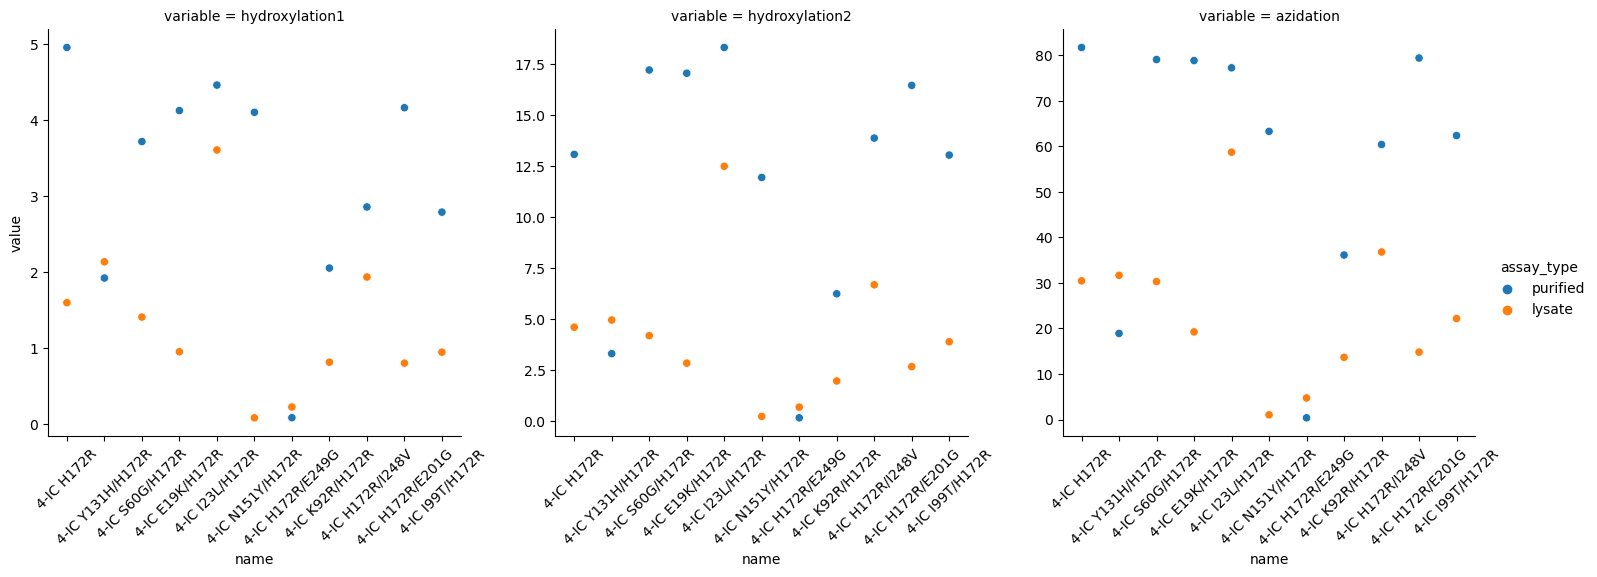

In [5]:
g = sns.relplot(data=df_ly_pur_melt, x="name", y="value", hue="assay_type", col="variable",
           facet_kws={'sharey': False}
)
g.set_xticklabels(rotation=45)
pass

In [6]:
df_ly_pur_melt_pivot = df_ly_pur_melt[["name", "variable", "value", "assay_type"]
                              ].pivot(index=["name", "variable"], columns="assay_type").reset_index()
df_ly_pur_melt_pivot.columns = ["name", "variable", "lysate_value", "purified_value"]

In [7]:
df_ly_pur_melt_pivot["lysate_value"] = df_ly_pur_melt_pivot.lysate_value.astype(float)
df_ly_pur_melt_pivot["purified_value"] = df_ly_pur_melt_pivot.purified_value.astype(float)

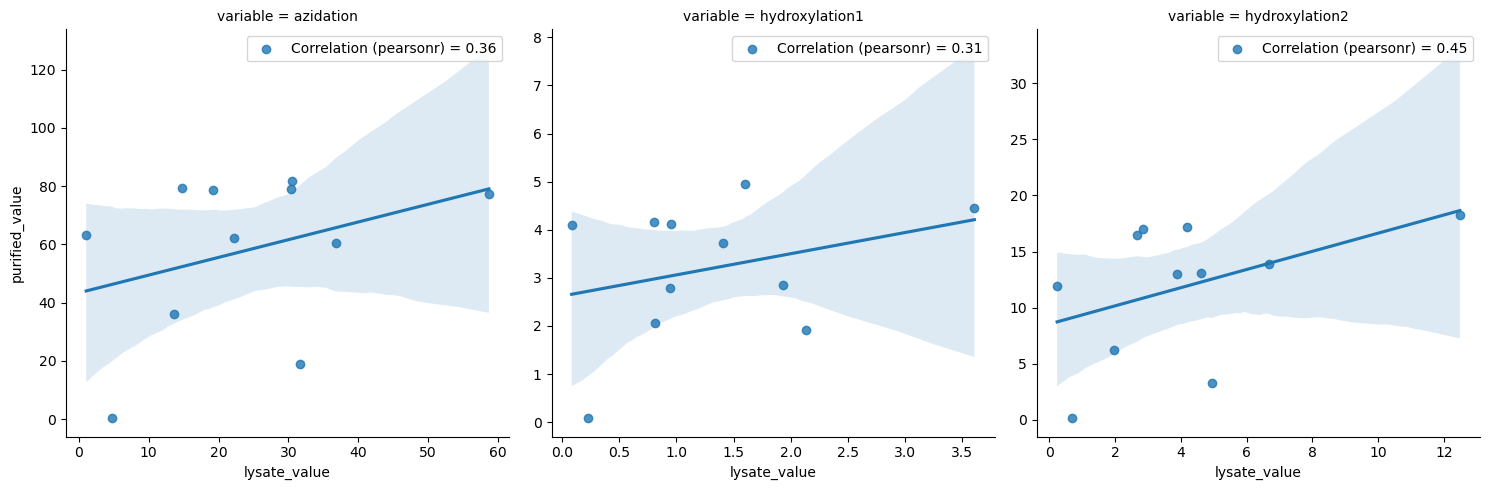

In [8]:
g = sns.lmplot(data=df_ly_pur_melt_pivot, x="lysate_value", y="purified_value", col="variable", 
          facet_kws={'sharey': False, 'sharex':False})

for ax, facet_data  in zip(g.axes.flat, g.facet_data()):
    facet_df = facet_data[1]
    r = pearsonr(facet_df.lysate_value, facet_df.purified_value).statistic
    ax.collections[0].set_label(f'Correlation (pearsonr) = {r:.2f}')
    ax.legend()

pass

### Purified protein

In [9]:
x = df_pure[["1_mol_azidation", "10_mol_azidation"]].dropna()
pearsonr(x["1_mol_azidation"], x["10_mol_azidation"])

PearsonRResult(statistic=0.6630286667115047, pvalue=0.001973852658636018)

In [10]:
df_pure_single_variant_multiple_tests = df_pure.groupby("parent_mutations").filter(lambda x: len(x) > 1)
df_pure_single_variant_multiple_tests

,name,parent,parent_mutations,aa_sequence,1_mol_hydroxylation1,1_mol_hydroxylation2,1_mol_azidation,10_mol_hydroxylation1,10_mol_hydroxylation2,10_mol_azidation
4,2-L,1-VH,F152L,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,3.748293,51.766776,41.267321,3.586251,45.587224,50.770114
14,2-L_06D-08,2-L,H172R,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,NaN,NaN,NaN,2.287183,29.816896,55.422825
19,SadX 23L,SadX,I23L,MQHTYPAQLMRFGTAARAEHMTLAAAIHALDADEADAIVMDIVPDG...,68.651848,0.682241,28.479321,74.818915,0.516879,24.47919
20,2-L 131H,2-L,Y131H,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,4.524928,36.061201,58.315657,5.864096,34.65481,56.760041
21,2-L 249G,2-L,E249G,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,0.242014,0.65071,3.294548,0.871289,2.371296,17.70268
22,3-VRL 23L,3-VRL,I23L,MQHTYPAQLMRFGTAARAEHMTLAAAIHALDADEADAVVMDIVPDG...,0.411827,1.417875,6.171578,0.963718,2.918999,16.266924
23,4-IC H172R,4-IC,H172R,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,NaN,NaN,NaN,4.954528,13.065421,81.685122
26,4-IC Y131H/H172R,4-IC H172R,Y131H,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,1.078785,2.561197,14.352144,1.92279,3.30813,18.915481
29,4-IC I23L/H172R,4-IC H172R,I23L,MQHTYPAQLMRFGTAARAEHMTLAAAIHALDADEADAIVMDIVPDG...,3.571246,12.939037,62.290763,4.460164,18.298813,77.217213
31,4-IC H172R/E249G,4-IC H172R,E249G,MQHTYPAQLMRFGTAARAEHMTIAAAIHALDADEADAIVMDIVPDG...,0.008452,0.031502,0.047388,0.086417,0.165675,0.384177


In [11]:
df_pure_parents = pd.DataFrame({"parents":df_pure_single_variant_multiple_tests.parent.unique()})

df_pure_parents["10_mol_azidation"] = \
    df_pure_parents.parents.map(lambda x: df_pure["10_mol_azidation"][df_pure.name == x].item())

In [12]:
df_pure_parents

,parents,10_mol_azidation
0,1-VH,31.618950
1,2-L,50.770114
2,SadX,31.253339
3,3-VRL,58.939442
4,4-IC,79.407772
5,4-IC H172R,81.685122
6,2-D,33.521160


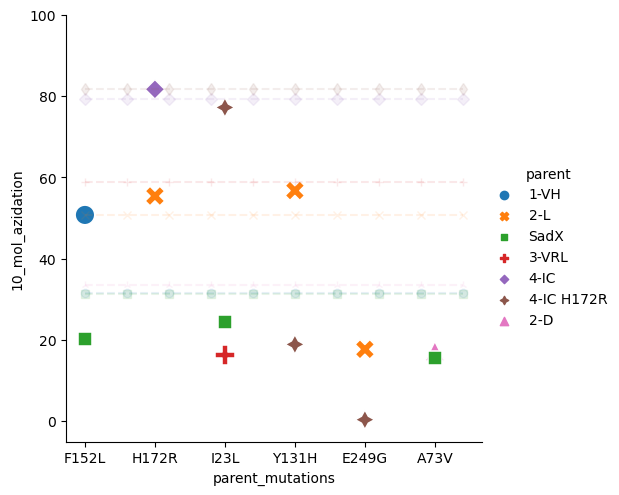

In [13]:
g = sns.relplot(data=df_pure_single_variant_multiple_tests, 
            x="parent_mutations", y="10_mol_azidation", hue="parent", 
            style="parent", s=200)

markers_list = ["o", "x", "s", "+", "D", "d", "2"]
ax = g.ax
for i, x in enumerate(g.legend.legendHandles):
    label = x.get_label()
    fc = x.get_fc()
    parent_val = df_pure_parents["10_mol_azidation"][df_pure_parents.parents == label].item()
    ax.plot(np.arange(0, 6, .6), np.repeat(parent_val, 10), color=fc, 
            linestyle="--",
            marker=markers_list[i], alpha=0.1)
g.set(ylim=(-5, 100))